# ICU Patient Outcome Prediction: Exploratory Data Analysis
**Objective:** To analyze physiological and clinical data from ICU patients to identify key predictors of in-hospital mortality. This exploratory analysis will inform the feature engineering and preprocessing steps required for building a robust predictive model.

## 1. Environment Setup & Data Ingestion
Importing essential libraries for data manipulation, statistical analysis, and visualization.

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt


Loading the dataset and displaying the initial records to verify successful ingestion and understand the structural format of the clinical variables.

In [2]:
data_path = Path("../data/raw")

X = pd.read_csv(data_path / "X_train_2025.csv")
y = pd.read_csv(data_path / "y_train_2025.csv")

df = pd.concat([X, y], axis=1)

df.head()


,recordid,SAPS-I,SOFA,Age,Gender,Height,Weight,CCU,CSRU,SICU,...,TroponinI_last,TroponinT_last,WBC_last,Weight_last,pH_last,MechVentStartTime,MechVentDuration,MechVentLast8Hour,UrineOutputSum,In-hospital_death
0,137517,-1,2,56.0,0.0,NaN,79.6,0,0,0,...,NaN,NaN,7.3,79.6,NaN,NaN,NaN,NaN,NaN,0
1,145680,10,3,72.0,1.0,NaN,70.0,0,0,0,...,NaN,0.07,2.4,70.0,7.48,NaN,NaN,NaN,NaN,0
2,138649,-1,8,81.0,0.0,NaN,NaN,0,0,0,...,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,0
3,149075,16,8,56.0,1.0,180.3,94.8,1,0,0,...,NaN,NaN,11.4,98.9,7.44,1128.0,470.0,0.0,4.0,0
4,141408,14,7,52.0,1.0,182.9,120.6,0,1,0,...,NaN,NaN,9.0,120.6,7.43,143.0,2580.0,1.0,16.0,0


In [3]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace("-", "_")
      .str.replace(" ", "_")
)

df.head()

,recordid,saps_i,sofa,age,gender,height,weight,ccu,csru,sicu,...,troponini_last,troponint_last,wbc_last,weight_last,ph_last,mechventstarttime,mechventduration,mechventlast8hour,urineoutputsum,in_hospital_death
0,137517,-1,2,56.0,0.0,NaN,79.6,0,0,0,...,NaN,NaN,7.3,79.6,NaN,NaN,NaN,NaN,NaN,0
1,145680,10,3,72.0,1.0,NaN,70.0,0,0,0,...,NaN,0.07,2.4,70.0,7.48,NaN,NaN,NaN,NaN,0
2,138649,-1,8,81.0,0.0,NaN,NaN,0,0,0,...,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,0
3,149075,16,8,56.0,1.0,180.3,94.8,1,0,0,...,NaN,NaN,11.4,98.9,7.44,1128.0,470.0,0.0,4.0,0
4,141408,14,7,52.0,1.0,182.9,120.6,0,1,0,...,NaN,NaN,9.0,120.6,7.43,143.0,2580.0,1.0,16.0,0


In [4]:
df.columns.tolist()

['recordid',
 'saps_i',
 'sofa',
 'age',
 'gender',
 'height',
 'weight',
 'ccu',
 'csru',
 'sicu',
 'diasabp_first',
 'gcs_first',
 'glucose_first',
 'hr_first',
 'map_first',
 'nidiasabp_first',
 'nimap_first',
 'nisysabp_first',
 'resprate_first',
 'sao2_first',
 'sysabp_first',
 'temp_first',
 'diasabp_last',
 'gcs_last',
 'glucose_last',
 'hr_last',
 'map_last',
 'nidiasabp_last',
 'nimap_last',
 'nisysabp_last',
 'resprate_last',
 'sao2_last',
 'sysabp_last',
 'temp_last',
 'diasabp_lowest',
 'gcs_lowest',
 'glucose_lowest',
 'hr_lowest',
 'map_lowest',
 'nidiasabp_lowest',
 'nimap_lowest',
 'nisysabp_lowest',
 'resprate_lowest',
 'sao2_lowest',
 'sysabp_lowest',
 'temp_lowest',
 'diasabp_highest',
 'gcs_highest',
 'glucose_highest',
 'hr_highest',
 'map_highest',
 'nidiasabp_highest',
 'nimap_highest',
 'nisysabp_highest',
 'resprate_highest',
 'sao2_highest',
 'sysabp_highest',
 'temp_highest',
 'diasabp_median',
 'gcs_median',
 'glucose_median',
 'hr_median',
 'map_median',
 '

In [5]:
df.shape

(3600, 121)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Columns: 121 entries, recordid to in_hospital_death
dtypes: float64(114), int64(7)
memory usage: 3.3 MB


In [7]:
df.describe()

,recordid,saps_i,sofa,age,gender,height,weight,ccu,csru,sicu,...,troponini_last,troponint_last,wbc_last,weight_last,ph_last,mechventstarttime,mechventduration,mechventlast8hour,urineoutputsum,in_hospital_death
count,3600.000000,3600.000000,3600.000000,3600.000000,3596.000000,1862.000000,3277.000000,3600.000000,3600.000000,3600.000000,...,175.000000,786.000000,3516.000000,2407.000000,2748.000000,2264.000000,2264.00000,2264.000000,2264.000000,3600.000000
mean,140964.911389,14.187500,6.311111,64.462778,0.563126,175.749198,81.729774,0.140556,0.213611,0.281944,...,6.714857,0.923537,12.361761,85.064769,7.399782,292.278269,1895.00530,0.617049,12.120141,0.139722
std,5583.521700,6.061105,4.191431,17.630796,0.496068,256.371473,23.677343,0.347611,0.409912,0.450009,...,9.643306,2.163239,6.309717,24.617355,0.060998,494.095873,876.76375,0.486214,5.818560,0.346747
min,132539.000000,-1.000000,-1.000000,15.000000,0.000000,121.900000,36.500000,0.000000,0.000000,0.000000,...,0.300000,0.010000,1.000000,36.200000,7.030000,0.000000,0.00000,0.000000,1.000000,0.000000
25%,136374.500000,11.000000,3.000000,53.000000,0.000000,162.600000,66.000000,0.000000,0.000000,0.000000,...,0.800000,0.040000,8.500000,68.300000,7.370000,52.000000,1140.00000,0.000000,7.000000,0.000000
50%,140071.500000,15.000000,6.000000,67.000000,1.000000,170.200000,79.000000,0.000000,0.000000,0.000000,...,1.700000,0.120000,11.300000,82.000000,7.410000,118.000000,2281.50000,1.000000,13.000000,0.000000
75%,145233.750000,18.000000,9.000000,78.000000,1.000000,177.800000,92.000000,0.000000,0.000000,1.000000,...,8.800000,0.567500,14.800000,97.400000,7.440000,241.000000,2670.00000,1.000000,16.000000,0.000000
max,152851.000000,34.000000,22.000000,90.000000,1.000000,11220.000000,280.000000,1.000000,1.000000,1.000000,...,46.000000,19.700000,130.900000,280.000000,7.630000,2854.000000,2880.00000,1.000000,38.000000,1.000000


The dataset contains ICU patient features including demographics, vital signs, and laboratory values. The objective is to predict patient mortality (hospital_death).

## 2. Target Variable Analysis: Class Imbalance
The primary outcome for this predictive task is `in_hospital_death`. It is critical to establish the baseline mortality rate and assess for class imbalance, as severe skewness will dictate our choice of evaluation metrics (e.g., PR-AUC over Accuracy) and sampling strategies (e.g., SMOTE) during model training.

In [8]:
df["in_hospital_death"].value_counts()

in_hospital_death
0    3097
1     503
Name: count, dtype: int64

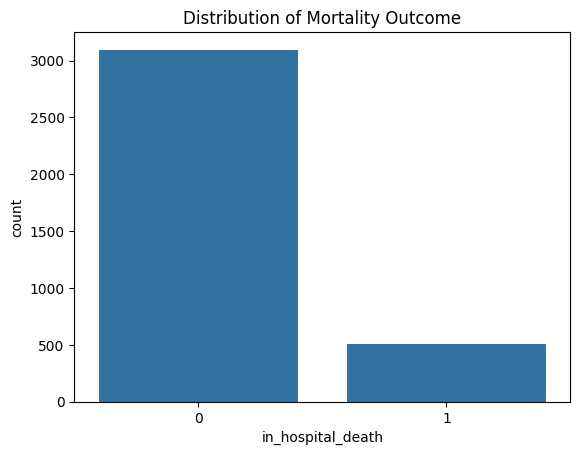

<Figure size 800x500 with 0 Axes>

In [9]:
sns.countplot(x="in_hospital_death", data=df)
plt.title("Distribution of Mortality Outcome")
plt.figure(figsize=(8,5))
plt.show()

In [10]:
df["in_hospital_death"].value_counts(normalize=True)

in_hospital_death
0    0.860278
1    0.139722
Name: proportion, dtype: float64

In [11]:
df.groupby("in_hospital_death")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
in_hospital_death,,,,,,,,
0,3097.0,63.536648,17.660578,15.0,52.0,66.0,78.0,90.0
1,503.0,70.165010,16.343505,18.0,60.5,74.0,83.0,90.0


Mortality outcomes are imbalanced, with significantly fewer death events than survivals. This imbalance will influence model evaluation and will require appropriate metrics such as ROC-AUC and PR-AUC.

## 3. Data Quality: Evaluating Missingness
Clinical datasets notoriously suffer from high missingness. We first visualize the proportion of missing data across all features to determine which variables require imputation and which might be too sparse to utilize directly.

In [12]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(20)

troponini_first      3425
troponini_last       3425
cholesterol_last     3325
cholesterol_first    3325
troponint_first      2814
troponint_last       2814
resprate_median      2606
resprate_lowest      2606
resprate_highest     2606
resprate_last        2606
resprate_first       2606
albumin_first        2128
albumin_last         2128
alp_first            2068
alp_last             2068
bilirubin_first      2041
bilirubin_last       2041
alt_last             2041
alt_first            2041
ast_first            2038
dtype: int64

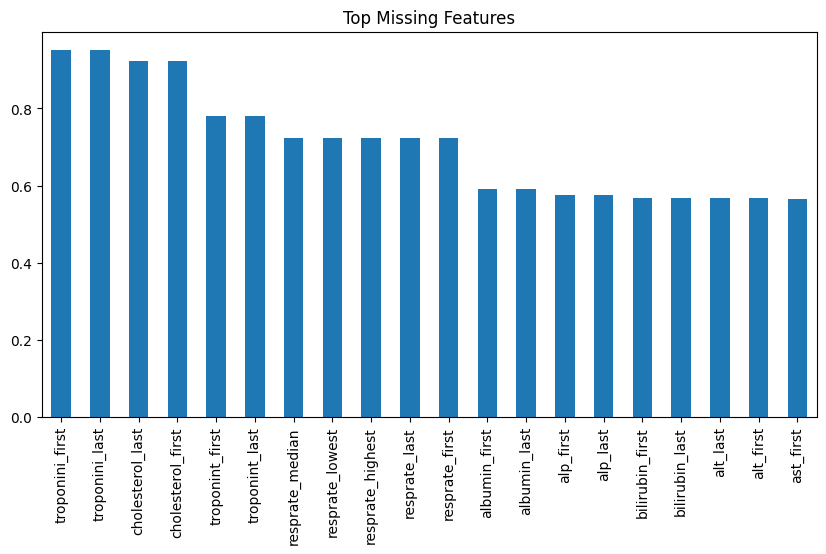

In [13]:
missing_ratio = df.isnull().mean().sort_values(ascending=False)

missing_ratio.head(20).plot(kind="bar", figsize=(10,5))
plt.title("Top Missing Features")
plt.show()

## Leverage Missingness: Clinical Suspicion Indicators
As noted earlier, high missingness in labs like troponin or lactate isn't random—it reflects clinical suspicion. Instead of simply imputing these with a mean or median, we will create explicit binary indicator columns (`is_missing`). This allows the machine learning model to learn from the physician's decision to order (or skip) a specific lab test.

Several laboratory measurements such as troponin, lactate, and bilirubin show substantial missingness. This likely reflects real clinical practice where these tests are ordered selectively based on suspected conditions, rather than routinely for all patients

In [14]:
# Create missingness indicators for highly missing critical labs
high_missing_labs = ['troponini_first', 'lactate_first', 'bilirubin_first']

for col in high_missing_labs:
    # 1 if missing, 0 if present
    df[f"{col}_is_missing"] = df[col].isnull().astype(int)

print("Created missingness indicators for:", high_missing_labs)

Created missingness indicators for: ['troponini_first', 'lactate_first', 'bilirubin_first']


## Outlier Investigation in Clinical Vitals
Medical data often contains charting errors or extreme physiological states. We will visualize key vital signs using boxplots to identify anomalous values (e.g., negative blood pressures or heart rates over 300) and establish a filtering or capping strategy before model training.

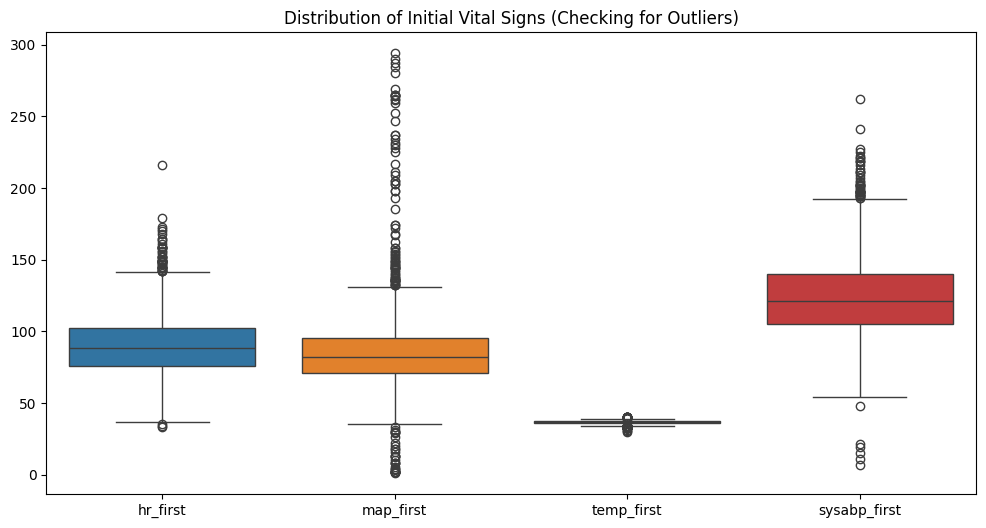

In [15]:
# Select key vitals for outlier visualization
vitals = ['hr_first', 'map_first', 'temp_first', 'sysabp_first']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[vitals])
plt.title("Distribution of Initial Vital Signs (Checking for Outliers)")
plt.show()

# Example: Cap extreme heart rates at the 99th percentile to reduce noise
hr_cap = df['hr_first'].quantile(0.99)
df['hr_first_capped'] = df['hr_first'].clip(upper=hr_cap)

## Temporal Dynamics: Capturing Patient Deterioration
The dataset captures multiple readings over time (e.g., `_first`, `_last`, `_highest`, `_lowest`). A patient's trajectory—whether they are stabilizing or deteriorating—is often more predictive of mortality than a single snapshot. We will engineer 'delta' and 'fluctuation' features to mathematically represent this change.

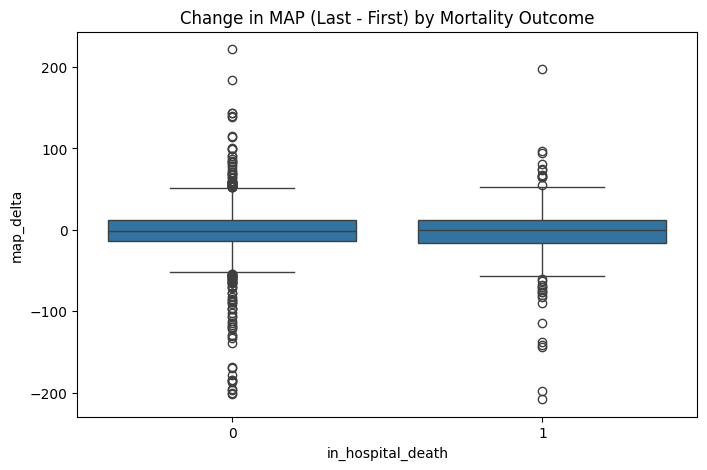

In [16]:
# Calculate the change in Mean Arterial Pressure (MAP) and Heart Rate
df['map_delta'] = df['map_last'] - df['map_first']
df['hr_delta'] = df['hr_last'] - df['hr_first']
df['map_fluctuation'] = df['map_highest'] - df['map_lowest']

# Visualize how MAP trajectory correlates with mortality
plt.figure(figsize=(8,5))
sns.boxplot(x='in_hospital_death', y='map_delta', data=df)
plt.title("Change in MAP (Last - First) by Mortality Outcome")
plt.show()

## Advanced Bivariate Analysis: Age, Severity Scores, and Mortality
To better understand the interaction between demographic factors and clinical severity, we will visualize how mortality rates shift across different combinations of Age and SAPS-I scores. This helps confirm if the standard severity metrics align with the outcomes in our specific cohort.

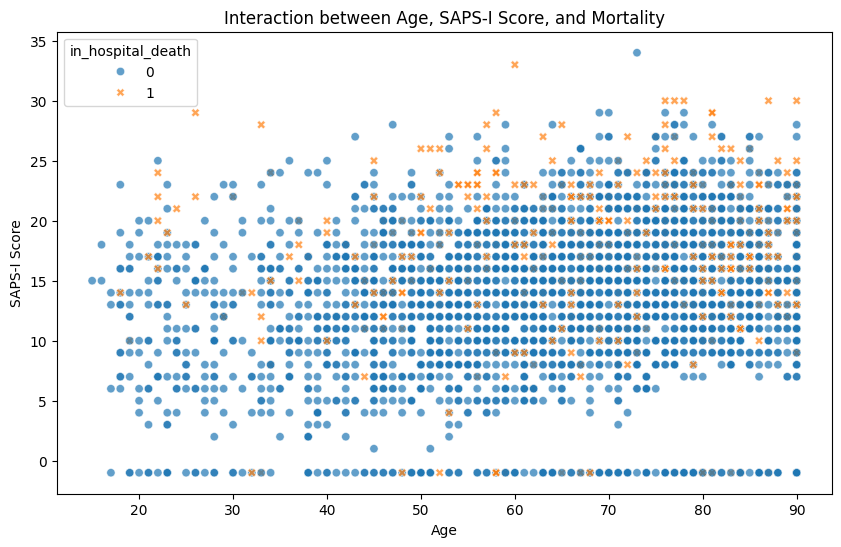

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='saps_i', hue='in_hospital_death', style='in_hospital_death', alpha=0.7, data=df)
plt.title("Interaction between Age, SAPS-I Score, and Mortality")
plt.xlabel("Age")
plt.ylabel("SAPS-I Score")
plt.show()

<Figure size 800x500 with 0 Axes>

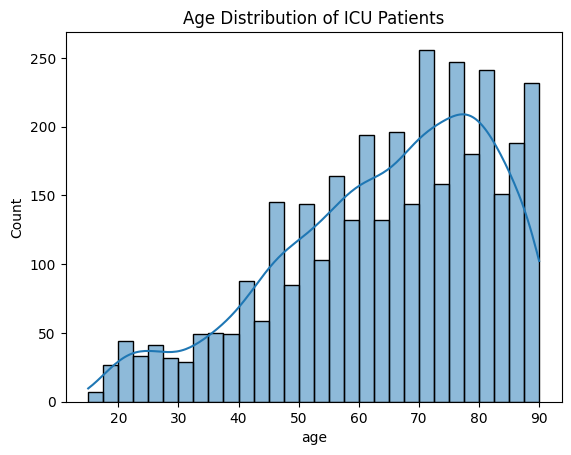

<Figure size 800x500 with 0 Axes>

In [18]:
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution of ICU Patients")
plt.figure(figsize=(8,5))

The age distribution shows a concentration of patients between approximately 50–90 years, consistent with ICU populations where older patients are more frequently admitted due to comorbidities and severe illness.

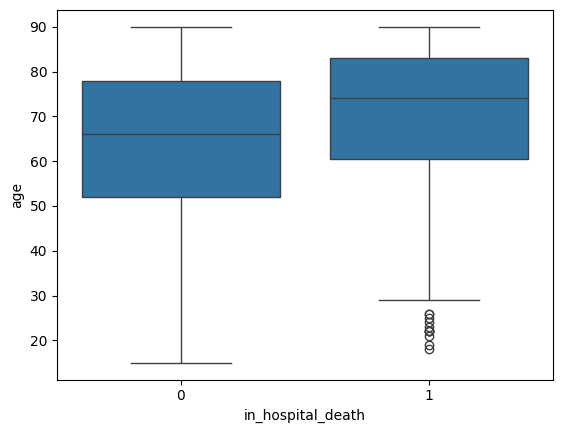

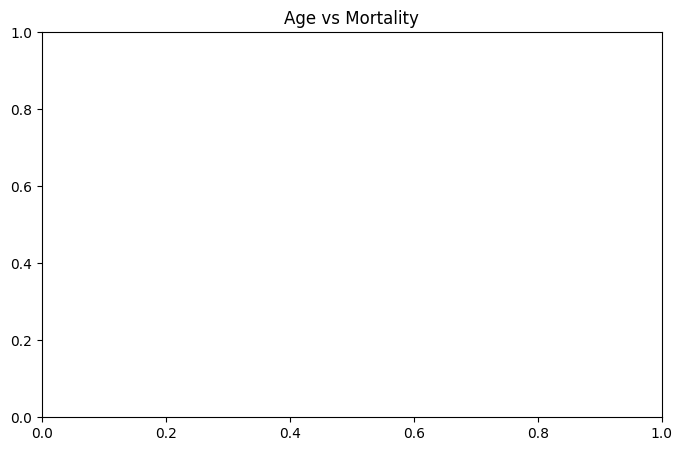

In [19]:
sns.boxplot(x="in_hospital_death", y="age", data=df)
plt.figure(figsize=(8,5))
plt.title("Age vs Mortality")
plt.show()

The median age among patients who died is noticeably higher than among survivors, suggesting that age is a significant risk factor for in-hospital mortality. This aligns with clinical expectations where advanced age is associated with reduced physiological resilience and increased comorbidity burden.

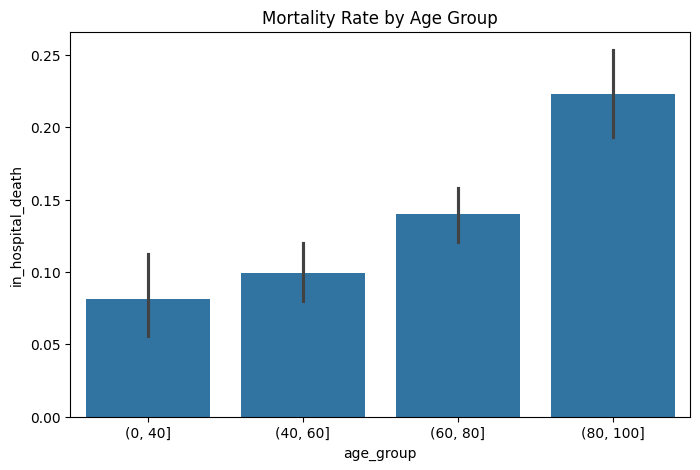

In [20]:
df["age_group"] = pd.cut(df["age"], bins=[0,40,60,80,100])

plt.figure(figsize=(8,5))
sns.barplot(x="age_group", y="in_hospital_death", data=df)
plt.title("Mortality Rate by Age Group")
plt.show()

Mortality risk increases significantly with age, particularly in patients above 60 years.

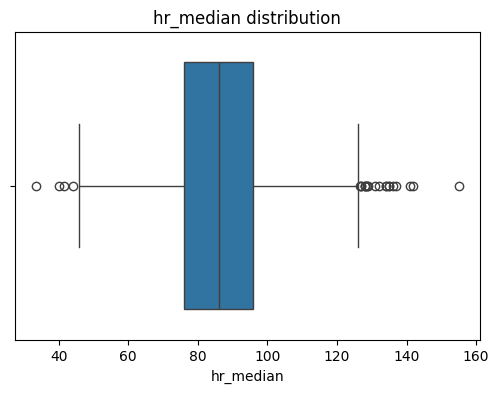

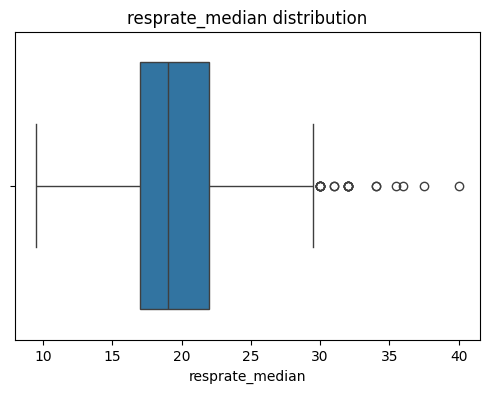

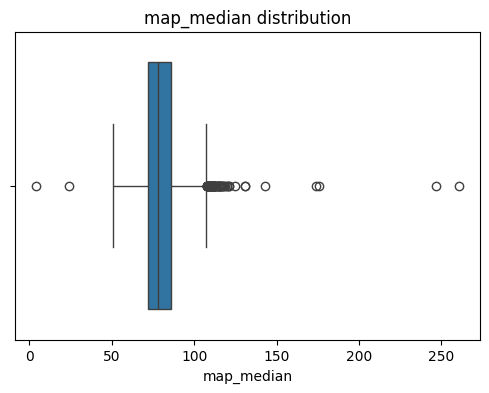

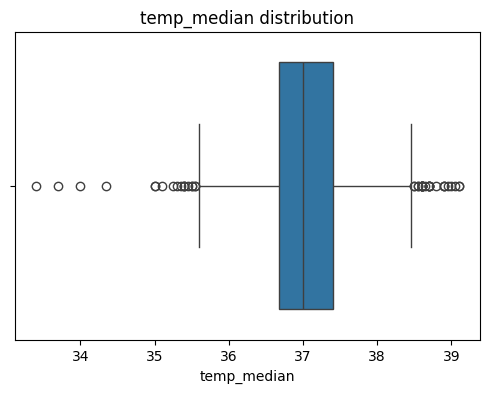

In [21]:
vitals = ["hr_median", "resprate_median", "map_median", "temp_median"]

for v in vitals:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[v])
    plt.title(f"{v} distribution")

Text(0.5, 1.0, 'Feature Correlation Matrix')

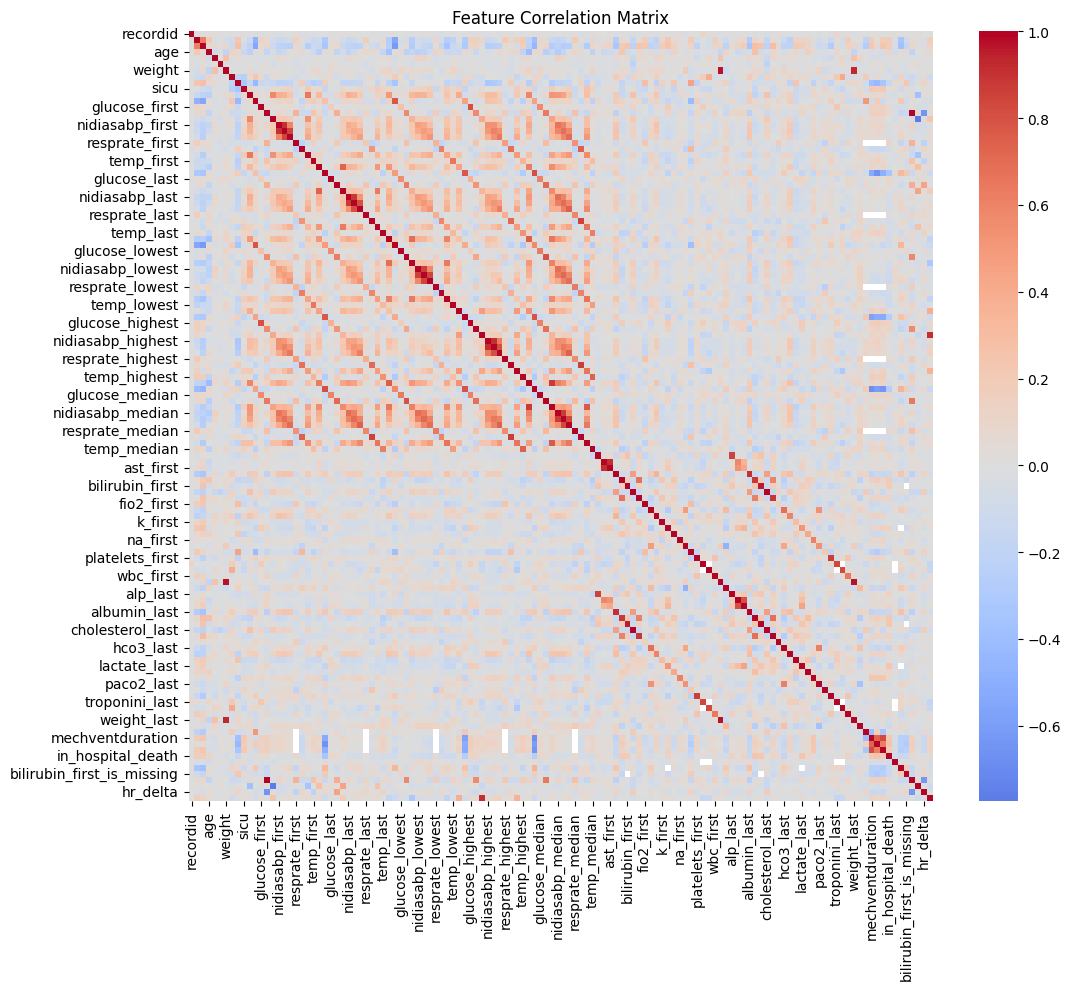

In [22]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")

Due to the large number of variables (>100), the full correlation matrix is difficult to interpret visually. Therefore, correlations with the target variable are extracted separately to identify the most relevant predictors of mortality.

In [23]:
corr = df.corr(numeric_only=True)["in_hospital_death"].sort_values(ascending=False)

corr.head(10)

in_hospital_death    1.000000
mechventlast8hour    0.262528
bun_last             0.242795
lactate_last         0.237088
mechventduration     0.227904
bilirubin_last       0.224304
bun_first            0.205582
bilirubin_first      0.193911
urineoutputsum       0.185702
sofa                 0.178469
Name: in_hospital_death, dtype: float64

Feature Exploration
- Data-driven discovery

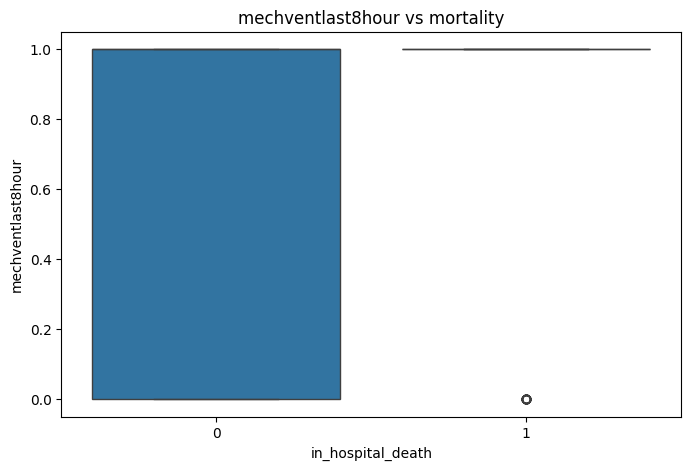

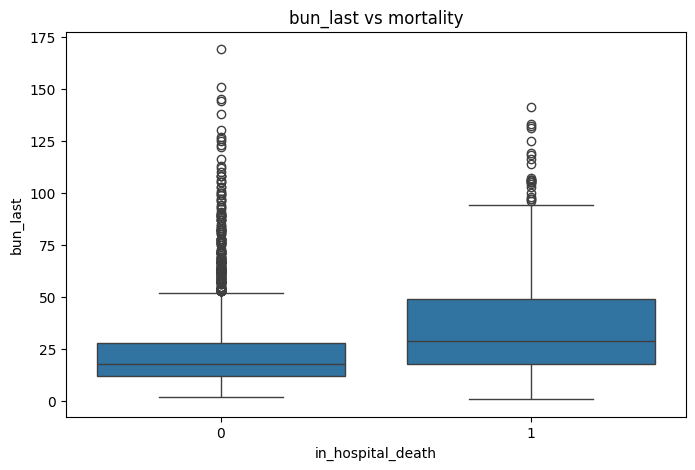

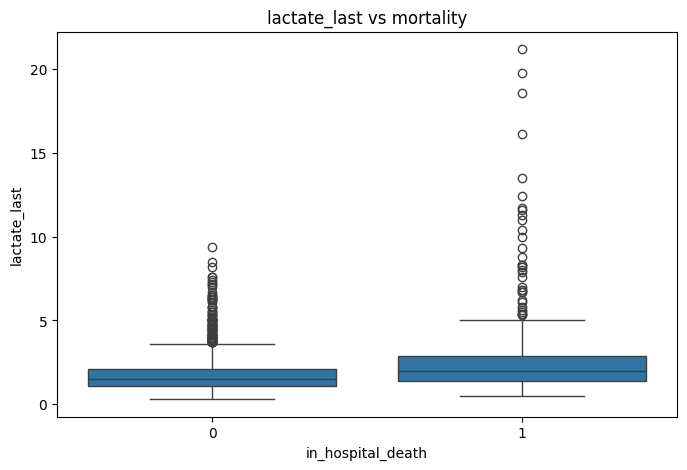

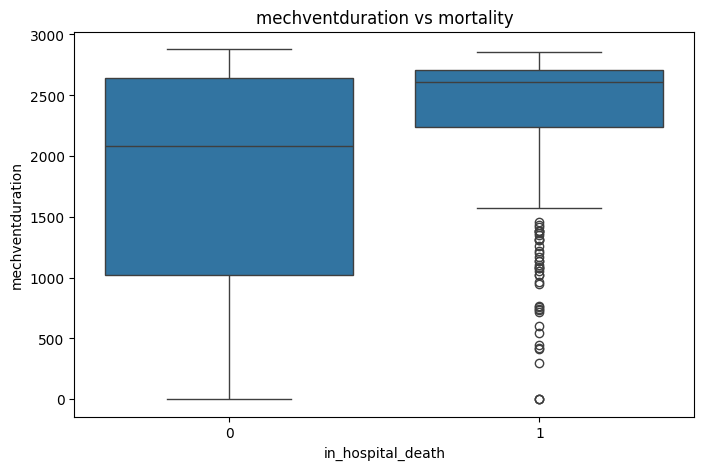

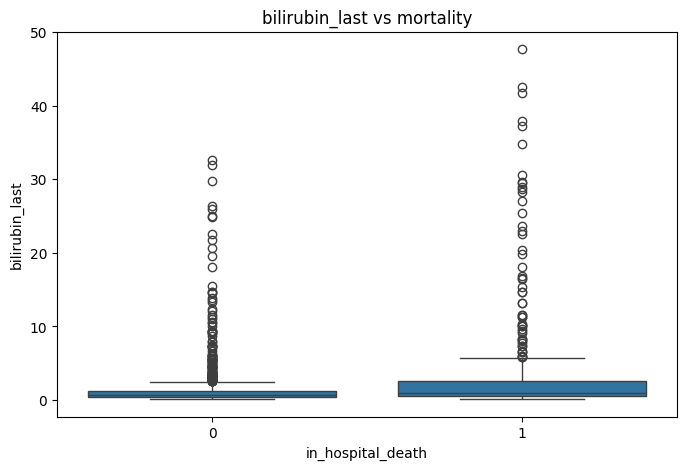

In [24]:
top_features = corr.index[1:6]

for f in top_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="in_hospital_death", y=f, data=df)
    plt.title(f"{f} vs mortality")
    plt.show()

The top features most correlated with mortality were identified programmatically. These variables highlight physiological and laboratory markers that may be strong predictors during model training.

Feature Exploration
- Domain-knowledge features

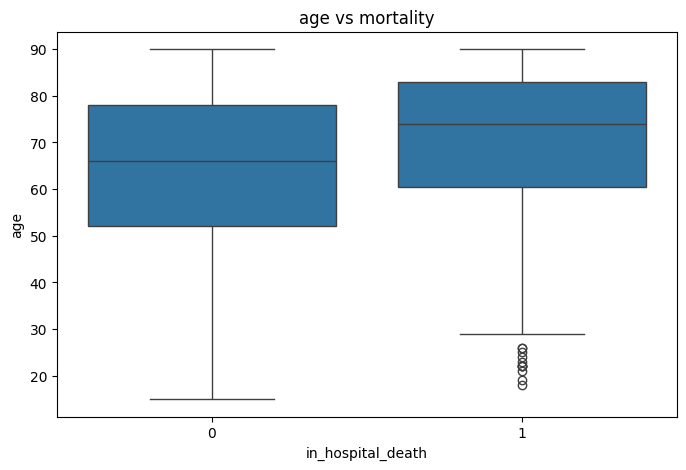

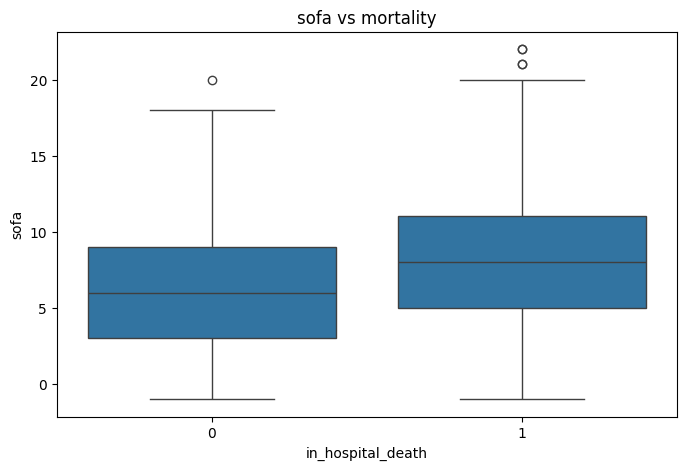

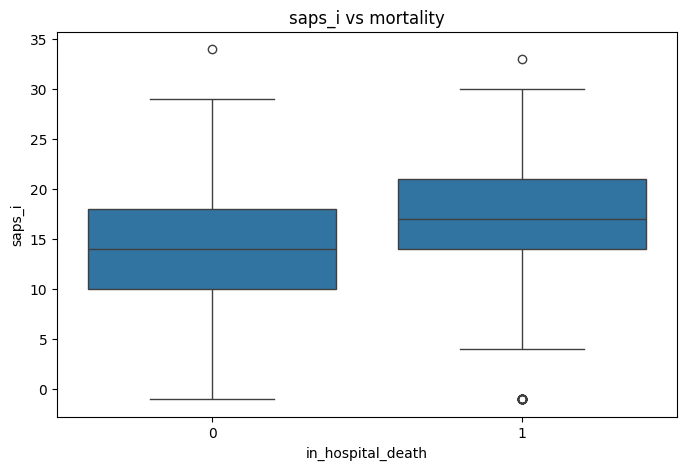

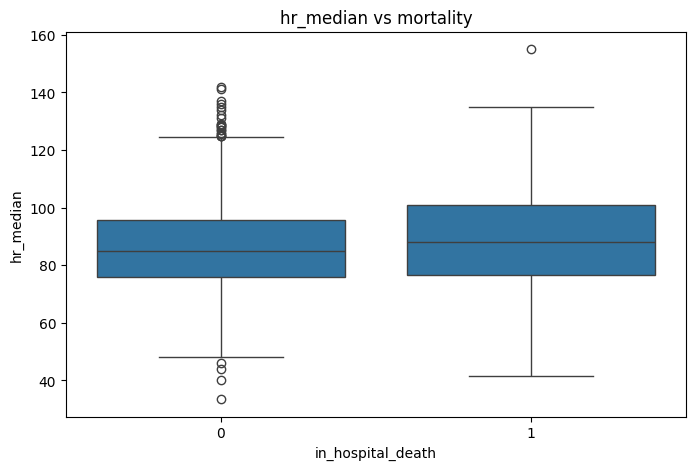

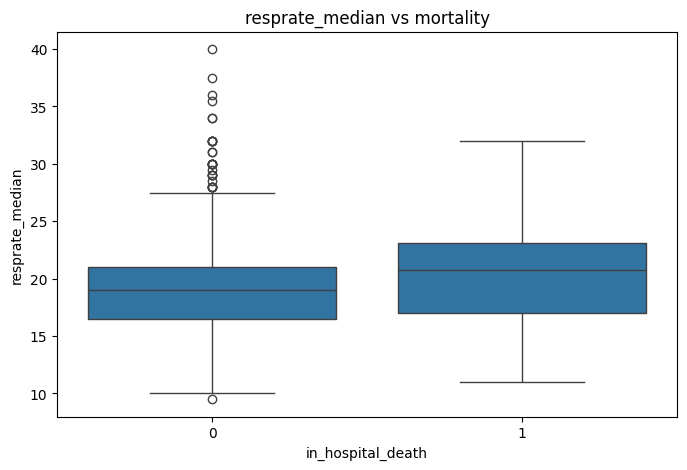

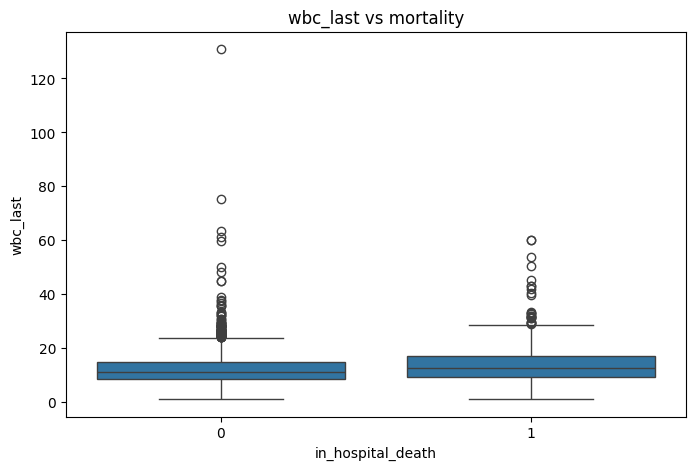

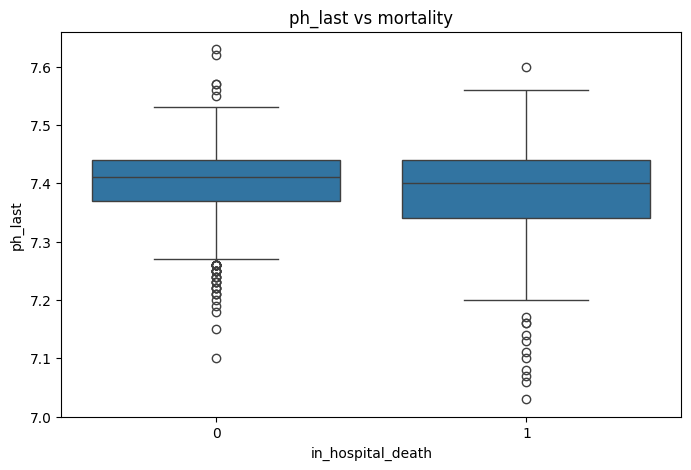

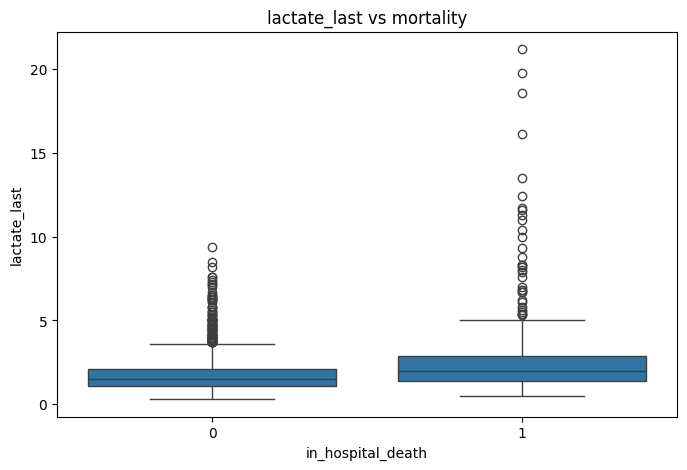

In [25]:
features = [
    "age",
    "sofa",
    "saps_i",
    "hr_median",
    "resprate_median",
    "wbc_last",
    "ph_last",
    "lactate_last"
]

for f in features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="in_hospital_death", y=f, data=df)
    plt.title(f"{f} vs mortality")
    plt.show()

<Axes: xlabel='age', ylabel='saps_i'>

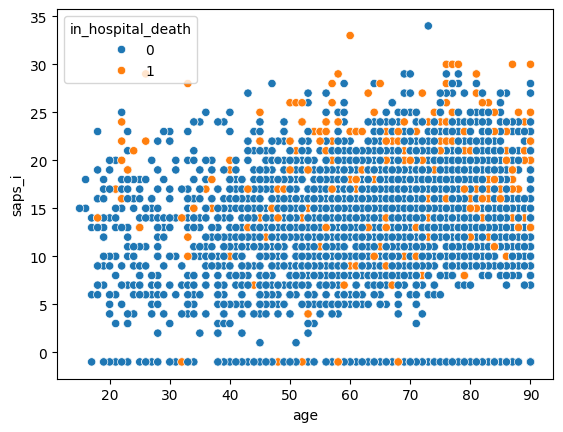

In [26]:
sns.scatterplot(
    x="age",
    y="saps_i",
    hue="in_hospital_death",
    data=df
)

In [27]:
# Save the final engineered dataset to a CSV file for the ML phase
# Setting index=False prevents pandas from writing row numbers as an extra column
df.to_csv('icu_data_engineered.csv', index=False)

print("Engineered dataset successfully saved as 'icu_data_engineered.csv'!")

Engineered dataset successfully saved as 'icu_data_engineered.csv'!


Severity scores such as SOFA and SAPS I show clear separation between survivors and non-survivors, indicating that physiological severity at admission is strongly associated with mortality risk.

## Clinical Interpretation of Feature Importance
Two complementary approaches were used to explore feature importance: a clinical review of severity scores/vitals and a data-driven correlation analysis against the mortality outcome.

**Key Findings:**
The most influential features in this dataset strongly reflect systemic organ dysfunction and acute critical illness severity. Specifically:
* **Respiratory & Hemodynamic Compromise:** Variables related to mechanical ventilation and fluctuating vital signs (MAP, Heart Rate) highlight the risk of cardiorespiratory failure.
* **Renal & Hepatic Impairment:** Elevated BUN, decreased urine output, and high bilirubin levels emerged as strong predictors, pointing to acute kidney injury and liver dysfunction.
* **Metabolic Stress:** Lactate levels serve as a critical proxy for tissue hypoperfusion and sepsis.

**Conclusion:**
These data-driven findings align perfectly with the epidemiological and clinical realities of ICU mortality, where multi-organ failure acts as the primary determinant of patient outcomes. The engineered temporal features (vital sign deltas) and missingness indicators will be carried forward into the predictive modeling pipeline to capture these complex clinical dynamics.